In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

def clean_stock_news_data(file_path: str, save_clean_path: str = None) -> pd.DataFrame:
    # 1. Load Dataset
    df = pd.read_csv("/content/stock_news_11_columns_6000rows.csv")
    print(f"Initial Dataset Shape: {df.shape}")

    # 2. Correct Date Formats & Sorting
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Drop rows where date parsing failed completely
    df = df.dropna(subset=['Date'])

    # Sort by ticker symbol and date for proper time-series operations
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    # 3. Handle Missing Values
    # Impute missing numerical data using forward fill then backward fill within each ticker group
    num_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility']
    df[num_cols] = df.groupby('Symbol')[num_cols].transform(lambda grp: grp.ffill().bfill())

    # Fill missing news headlines if any
    if 'News_Headline' in df.columns:
        df['News_Headline'] = df['News_Headline'].fillna('No News Available').astype(str).str.strip()

    # 4. Remove Duplicates
    # Remove identical date-symbol pairs, keeping the latest entry
    before_dedup = len(df)
    df = df.drop_duplicates(subset=['Date', 'Symbol'], keep='last')
    print(f"Duplicates Removed: {before_dedup - len(df)}")

    # 5. Check & Filter Invalid Values
    # Ensure prices and volume are non-negative
    valid_price_mask = (df['Open'] > 0) & (df['High'] > 0) & (df['Low'] > 0) & (df['Close'] > 0) & (df['Volume'] >= 0)

    # Verify logical high/low boundary constraints
    logical_bound_mask = (df['High'] >= df['Low']) & \
                         (df['High'] >= df['Open']) & \
                         (df['High'] >= df['Close']) & \
                         (df['Low'] <= df['Open']) & \
                         (df['Low'] <= df['Close'])

    df = df[valid_price_mask & logical_bound_mask]

    # Clip sentiment scores to ensure strict adherence to [-1.0, 1.0] range
    df['Sentiment_Score'] = df['Sentiment_Score'].clip(-1.0, 1.0)

    # Standardize string formatting for Symbols
    df['Symbol'] = df['Symbol'].astype(str).str.strip().str.upper()

    # 6. Standardize Numerical Columns (Scaling)
    scaler = StandardScaler()
    scaled_cols = [f"{col}_scaled" for col in num_cols]
    df[scaled_cols] = scaler.fit_transform(df[num_cols])

    # 7. Final Dataset Inspection
    print(f"Cleaned Dataset Shape: {df.shape}")
    print(f"Missing Values Count across all columns:\n{df.isnull().sum()}")

    # Save cleaned file if path is specified
    if save_clean_path:
        # Ensure the directory exists before saving
        output_dir = os.path.dirname(save_clean_path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        df.to_csv(save_clean_path, index=False)
        print(f"\nCleaned dataset successfully saved to: {save_clean_path}")

    return df

# Execute the cleaning routine
if __name__ == "__main__":
    cleaned_df = clean_stock_news_data(
        file_path='stock_news_11_columns_6000rows.csv',
        save_clean_path='data/processed/cleaned_stock_news.csv'
    )
    print("\nCleaned Data Preview:")
    print(cleaned_df[['Date', 'Symbol', 'Close', 'Close_scaled', 'Sentiment_Score', 'Target']].head())

Initial Dataset Shape: (6000, 11)
Duplicates Removed: 0
Cleaned Dataset Shape: (6000, 18)
Missing Values Count across all columns:
Date                      0
Symbol                    0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
News_Headline             0
Sentiment_Score           0
Volatility                0
Target                    0
Open_scaled               0
High_scaled               0
Low_scaled                0
Close_scaled              0
Volume_scaled             0
Sentiment_Score_scaled    0
Volatility_scaled         0
dtype: int64

Cleaned dataset successfully saved to: data/processed/cleaned_stock_news.csv

Cleaned Data Preview:
        Date    Symbol      Close  Close_scaled  Sentiment_Score  Target
0 2014-06-17  ADANIENT  68.090887     -0.779380             -1.0       0
1 2014-06-20  ADANIENT  63.122749     -0.782064             -1.0       0
2 2014-07-30  ADANIENT  62.16375

In [2]:
import sqlite3
import pandas as pd

def store_data_to_sql(csv_path: str, db_path: str = "stock_market.db"):
    # 1. Load cleaned data
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Sort chronologically by Symbol and Date
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    # 2. Compute Daily Return for return analysis
    df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

    # 3. Connect to SQLite Database
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # 4. Create SQL Table Schema
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS stock_sentiment_data (
        Date TEXT,
        Symbol TEXT,
        Open REAL,
        High REAL,
        Low REAL,
        Close REAL,
        Volume INTEGER,
        News_Headline TEXT,
        Sentiment_Score REAL,
        Volatility REAL,
        Target INTEGER,
        Daily_Return REAL,
        PRIMARY KEY (Symbol, Date)
    );
    """)

    # 5. Insert Cleaned Data into Database
    df.to_sql('stock_sentiment_data', conn, if_exists='replace', index=False)
    conn.commit()
    conn.close()
    print(f"Data successfully stored into '{db_path}' database in table 'stock_sentiment_data'.")

if __name__ == "__main__":
    store_data_to_sql('data/processed/cleaned_stock_news.csv')

Data successfully stored into 'stock_market.db' database in table 'stock_sentiment_data'.


In [3]:


# Connect to the SQLite database
conn = sqlite3.connect('stock_market.db')

# SQL query as a string
sql_query = """
SELECT
    Symbol,
    COUNT(*) AS Total_Trading_Days,
    ROUND(AVG(Close), 2) AS Avg_Close_Price,
    ROUND(MIN(Low), 2) AS Min_Low_Price,
    ROUND(MAX(High), 2) AS Max_High_Price,
    ROUND(AVG(Daily_Return) * 100, 4) AS Avg_Daily_Return_Pct,
    ROUND(AVG(Volume), 0) AS Avg_Trading_Volume,
    ROUND(AVG(Volatility), 4) AS Avg_Volatility,
    ROUND(AVG(Sentiment_Score), 4) AS Avg_Sentiment_Score
FROM stock_sentiment_data
GROUP BY Symbol
ORDER BY Avg_Daily_Return_Pct DESC;
"""

# Execute the query and load results into a DataFrame
query_results = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Display the results
print("Aggregated Stock Performance by Symbol:")
print(query_results.head())

Aggregated Stock Performance by Symbol:
       Symbol  Total_Trading_Days  Avg_Close_Price  Min_Low_Price  \
0  TATACONSUM                  20           879.85         107.26   
1      GRASIM                  27          2247.94         505.67   
2     HCLTECH                  62           934.91          19.74   
3  BAJFINANCE                 208          5484.08          54.84   
4    AXISBANK                  10           368.72         232.99   

   Max_High_Price  Avg_Daily_Return_Pct  Avg_Trading_Volume  Avg_Volatility  \
0         1218.91               33.5905           2974440.0          0.0157   
1         2839.39               11.5071            684084.0          0.0133   
2         1916.79               11.1521           3433127.0          0.0145   
3         8049.71                9.8882           3032973.0          0.0222   
4          531.38                9.8221           9375769.0          0.0214   

   Avg_Sentiment_Score  
0               0.2500  
1              -0.03

In [4]:


# Connect to the SQLite database
conn = sqlite3.connect('stock_market.db')

# SQL query as a string
sql_query = """
SELECT
    Symbol,
    ROUND(AVG(Volatility), 4) AS Avg_Daily_Volatility,
    ROUND(MAX(Volatility), 4) AS Peak_Volatility,
    ROUND(AVG(High - Low), 2) AS Avg_Daily_Price_Spread,
    ROUND(AVG(Volume), 0) AS Avg_Volume
FROM stock_sentiment_data
GROUP BY Symbol
HAVING COUNT(*) >= 10
ORDER BY Avg_Daily_Volatility DESC;
"""

# Execute the query and load results into a DataFrame
volatility_analysis = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Display the results
print("Stock Volatility Analysis (Min. 10 Trading Days):")
print(volatility_analysis.head())

Stock Volatility Analysis (Min. 10 Trading Days):
       Symbol  Avg_Daily_Volatility  Peak_Volatility  Avg_Daily_Price_Spread  \
0    ADANIENT                0.0321           0.1187                   42.74   
1    HINDALCO                0.0228           0.0640                   12.87   
2  ADANIPORTS                0.0224           0.0707                   17.84   
3  BAJFINANCE                0.0222           0.0865                  161.44   
4    AXISBANK                0.0214           0.0307                   11.67   

   Avg_Volume  
0   7677821.0  
1   7325146.0  
2   6785658.0  
3   3032973.0  
4   9375769.0  


In [5]:


# Connect to the SQLite database
conn = sqlite3.connect('stock_market.db')

# SQL query as a string
sql_query = """
SELECT
    Symbol,
    CASE
        WHEN Sentiment_Score > 0.1 THEN 'Positive'
        WHEN Sentiment_Score < -0.1 THEN 'Negative'
        ELSE 'Neutral'
    END AS Sentiment_Category,
    COUNT(*) AS Headline_Count,
    ROUND(AVG(Daily_Return) * 100, 4) AS Avg_Return_Pct,
    ROUND(AVG(Target) * 100, 2) AS Up_Movement_Win_Rate_Pct
FROM stock_sentiment_data
GROUP BY Symbol, Sentiment_Category
ORDER BY Symbol, Headline_Count DESC;
"""

# Execute the query and load results into a DataFrame
sentiment_performance = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Display the results
print("Stock Performance by Sentiment Category:")
print(sentiment_performance.head())

Stock Performance by Sentiment Category:
       Symbol Sentiment_Category  Headline_Count  Avg_Return_Pct  \
0    ADANIENT            Neutral             132          2.1589   
1    ADANIENT           Negative              75          1.6001   
2    ADANIENT           Positive              60          2.8544   
3  ADANIPORTS            Neutral             234          0.8284   
4  ADANIPORTS           Negative             102          0.1093   

   Up_Movement_Win_Rate_Pct  
0                     55.30  
1                     46.67  
2                     63.33  
3                     49.57  
4                     43.14  


In [6]:


# Connect to the SQLite database
conn = sqlite3.connect('stock_market.db')

# SQL query as a string
sql_query = """
SELECT
    Symbol,
    ROUND(AVG(Volume), 0) AS Avg_Daily_Volume,
    ROUND(MAX(Volume), 0) AS Max_Daily_Volume,
    ROUND(AVG(Volume * Close), 2) AS Avg_Traded_Value
FROM stock_sentiment_data
GROUP BY Symbol
ORDER BY Avg_Traded_Value DESC
LIMIT 10;
"""

# Execute the query and load results into a DataFrame
trading_volume_analysis = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Display the results
print("Top 10 Stocks by Average Traded Value:")
print(trading_volume_analysis.head(10))

Top 10 Stocks by Average Traded Value:
       Symbol  Avg_Daily_Volume  Max_Daily_Volume  Avg_Traded_Value
0    RELIANCE        19868685.0       104511743.0      1.606142e+10
1  BAJFINANCE         3032973.0        27130743.0      1.332528e+10
2        SBIN        22165699.0        65009240.0      9.447798e+09
3   SUNPHARMA        10077269.0       267723750.0      9.051688e+09
4     DRREDDY        10211142.0       115799397.0      8.957100e+09
5        INFY         9821869.0        74069600.0      8.644306e+09
6   KOTAKBANK         4308622.0        18249030.0      7.313089e+09
7  BHARTIARTL        10796238.0       194207079.0      5.761858e+09
8         TCS         2435642.0         9589062.0      5.299546e+09
9    ADANIENT         7677821.0        69112255.0      5.270185e+09


In [7]:


def execute_sql_analysis(db_path: str = "stock_market.db"):
    conn = sqlite3.connect(db_path)

    print("--- 1. Company-Wise Financial Metrics Summary ---")
    q1 = """
    SELECT
        Symbol,
        COUNT(*) AS Days,
        ROUND(AVG(Close), 2) AS Avg_Close,
        ROUND(AVG(Daily_Return) * 100, 2) AS Avg_Return_Pct,
        ROUND(AVG(Volume), 0) AS Avg_Volume,
        ROUND(AVG(Volatility), 4) AS Avg_Volatility,
        ROUND(AVG(Sentiment_Score), 2) AS Avg_Sentiment
    FROM stock_sentiment_data
    GROUP BY Symbol
    ORDER BY Avg_Return_Pct DESC
    LIMIT 10;
    """
    df_summary = pd.read_sql_query(q1, conn)
    print(df_summary.to_string(index=False))

    print("\n--- 2. Sentiment Impact Analysis ---")
    q2 = """
    SELECT
        CASE
            WHEN Sentiment_Score > 0.1 THEN 'Positive'
            WHEN Sentiment_Score < -0.1 THEN 'Negative'
            ELSE 'Neutral'
        END AS Sentiment_Category,
        COUNT(*) AS Headline_Count,
        ROUND(AVG(Daily_Return) * 100, 4) AS Avg_Return_Pct,
        ROUND(AVG(Target) * 100, 2) AS Up_Movement_Win_Rate_Pct
    FROM stock_sentiment_data
    GROUP BY Sentiment_Category;
    """
    df_sentiment = pd.read_sql_query(q2, conn)
    print(df_sentiment.to_string(index=False))

    conn.close()

if __name__ == "__main__":
    execute_sql_analysis()

--- 1. Company-Wise Financial Metrics Summary ---
    Symbol  Days  Avg_Close  Avg_Return_Pct  Avg_Volume  Avg_Volatility  Avg_Sentiment
TATACONSUM    20     879.85           33.59   2974440.0          0.0157           0.25
    GRASIM    27    2247.94           11.51    684084.0          0.0133          -0.04
   HCLTECH    62     934.91           11.15   3433127.0          0.0145           0.05
BAJFINANCE   208    5484.08            9.89   3032973.0          0.0222          -0.10
  AXISBANK    10     368.72            9.82   9375769.0          0.0214          -0.40
ULTRACEMCO    52    8009.95            9.63    375682.0          0.0152           0.00
  HINDALCO    35     477.63            7.50   7325146.0          0.0228          -0.17
   DRREDDY    27     870.79            6.21  10211142.0          0.0174          -0.15
  JSWSTEEL    42     694.67            6.20   2786020.0          0.0141          -0.02
      SBIN    57     480.05            6.18  22165699.0          0.0175         

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [9]:
df = pd.read_csv('data/processed/cleaned_stock_news.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

In [10]:
num_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility']
print(df[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

                  count          mean           std       min           50%  \
Open             6000.0  1.511405e+03  1.851873e+03  8.261796  8.815945e+02   
High             6000.0  1.528552e+03  1.871224e+03  8.425484  8.915145e+02   
Low              6000.0  1.491978e+03  1.829948e+03  8.140351  8.701109e+02   
Close            6000.0  1.510353e+03  1.850680e+03  8.293478  8.824170e+02   
Volume           6000.0  8.543745e+06  1.814969e+07  1.000000  3.279215e+06   
Sentiment_Score  6000.0  2.623016e-04  6.334469e-01 -1.000000  0.000000e+00   
Volatility       6000.0  1.802207e-02  9.488744e-03  0.003461  1.589956e-02   

                          max  
Open             1.338048e+04  
High             1.353910e+04  
Low              1.327195e+04  
Close            1.349306e+04  
Volume           2.815185e+08  
Sentiment_Score  1.000000e+00  
Volatility       1.186553e-01  


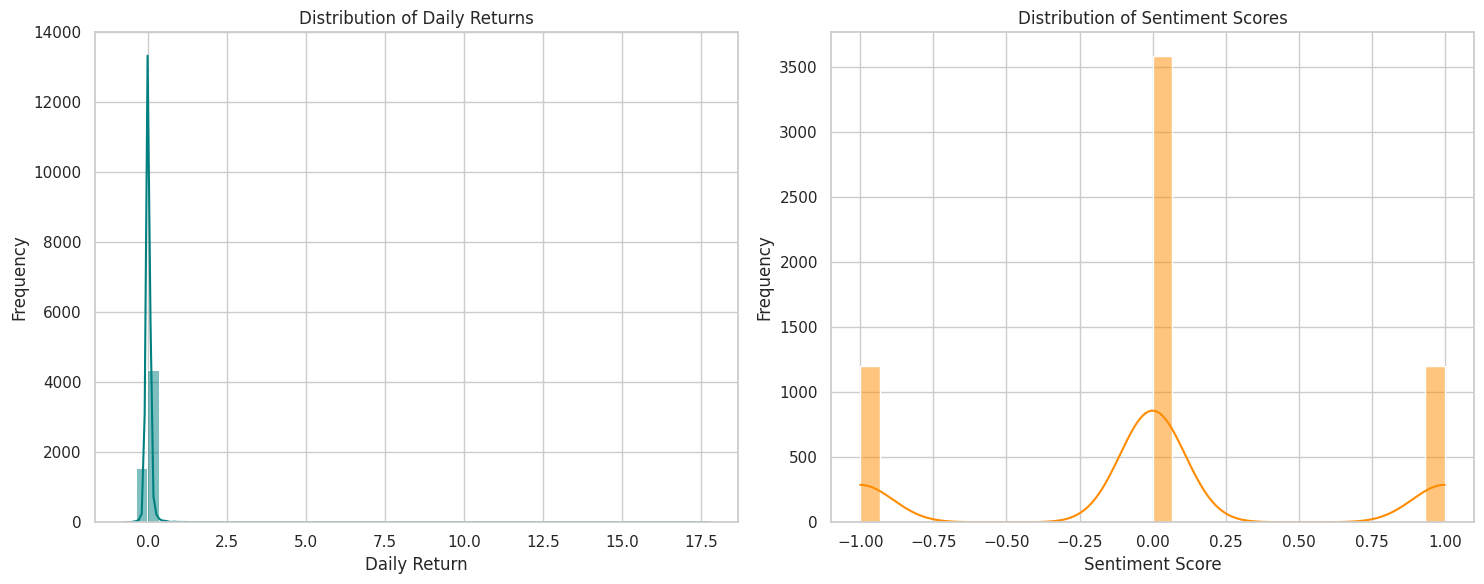

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Daily Return Distribution
sns.histplot(df['Daily_Return'].dropna(), kde=True, ax=axes[0], color='teal', bins=50)
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# Plot 2: Sentiment Score Distribution
sns.histplot(df['Sentiment_Score'], kde=True, ax=axes[1], color='darkorange', bins=30)
axes[1].set_title('Distribution of Sentiment Scores')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

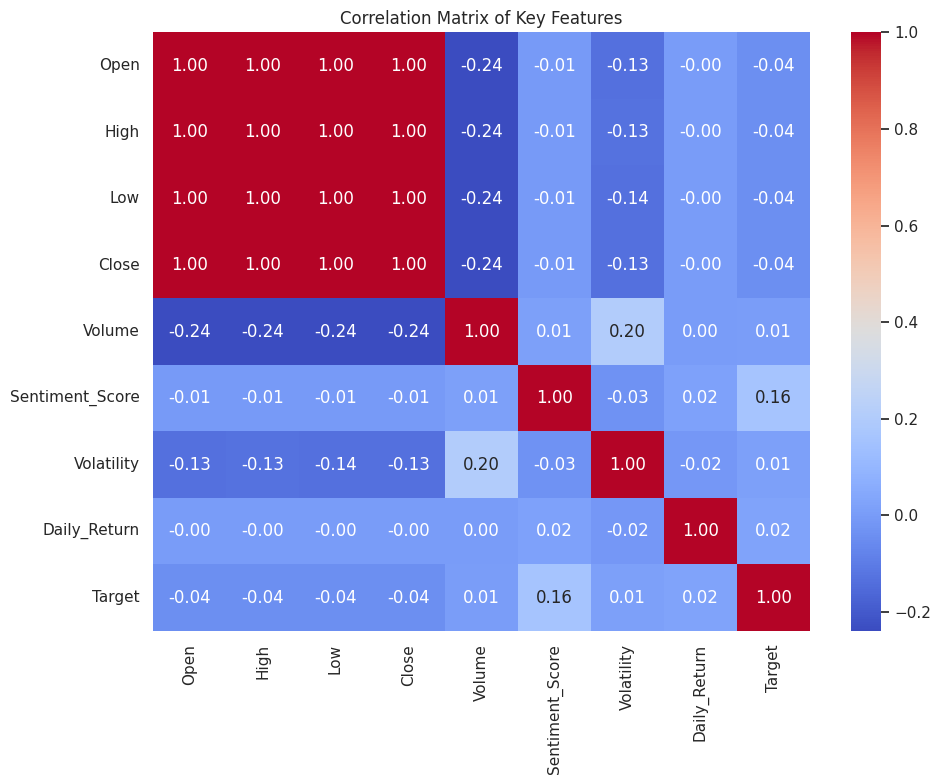

In [12]:
fig_corr, ax_corr = plt.subplots(figsize=(10, 8))
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility', 'Daily_Return', 'Target']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax_corr)
ax_corr.set_title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

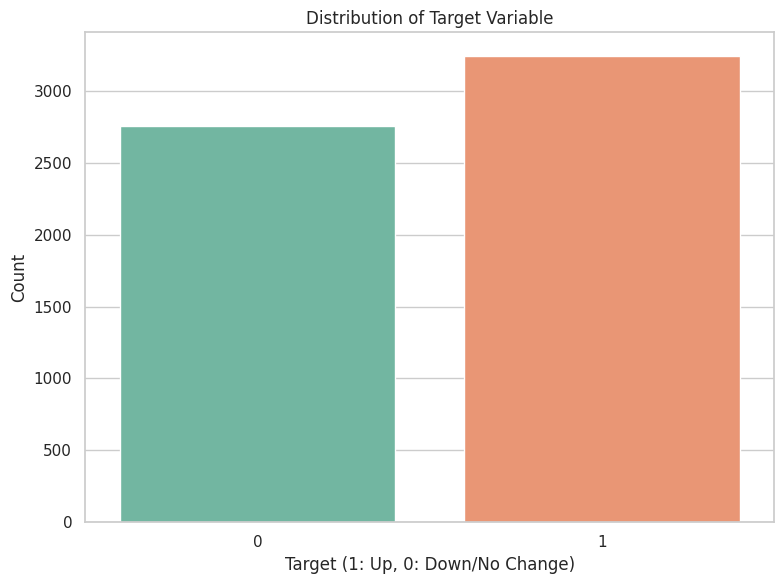

In [13]:
fig_target, ax_target = plt.subplots(figsize=(8, 6))
sns.countplot(x='Target', data=df, ax=ax_target, palette='Set2', hue='Target', legend=False)
ax_target.set_title('Distribution of Target Variable')
ax_target.set_xlabel('Target (1: Up, 0: Down/No Change)')
ax_target.set_ylabel('Count')
plt.tight_layout()
plt.show()

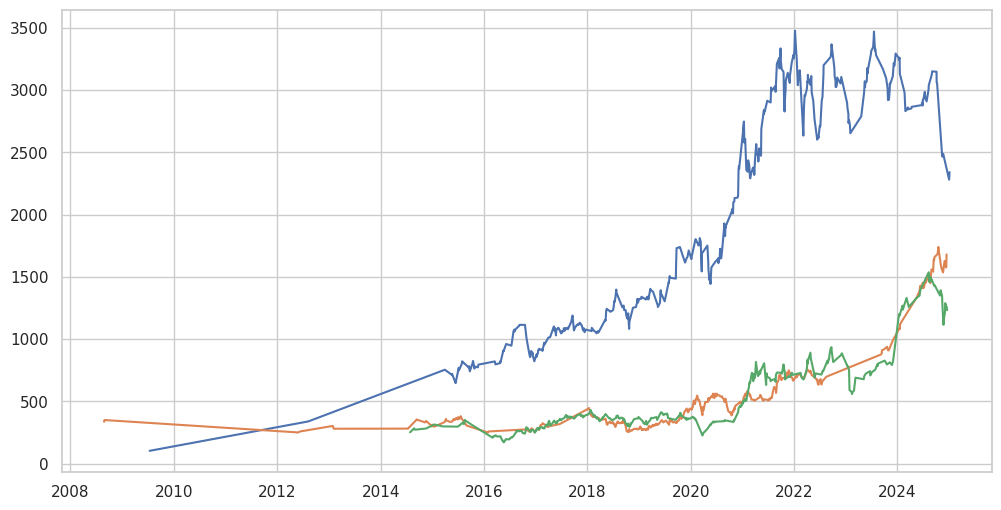

In [14]:
top_symbols = df['Symbol'].value_counts().head(3).index.tolist()

for symbol in top_symbols:
    stock_data = df[df['Symbol'] == symbol]
    plt.plot(stock_data['Date'], stock_data['Close'], label=f"{symbol} Close Price")

/tmp/ipykernel_1202/3575330891.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Sentiment_Score', data=df, palette='Set3')


<Axes: xlabel='Target', ylabel='Sentiment_Score'>

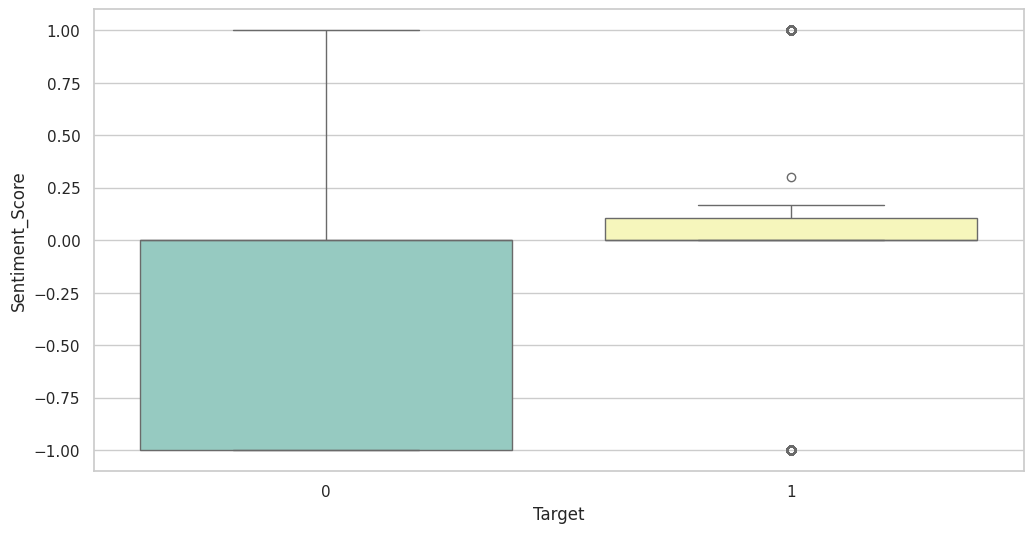

In [15]:
sns.boxplot(x='Target', y='Sentiment_Score', data=df, palette='Set3')

In [16]:
import pandas as pd
import numpy as np

def cap_outliers_iqr(df: pd.DataFrame) -> pd.DataFrame:
    """
    Corrects outliers using the Interquartile Range (IQR) method without removing rows.
    Extreme values are capped to boundary limits (Winsorization).
    """
    df_capped = df.copy()

    # 1. Continuous Market Metrics: Global IQR Capping
    continuous_cols = ['Volume', 'Volatility']

    for col in continuous_cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = max(0.0, Q1 - 1.5 * IQR)  # Volume & volatility cannot be negative
        upper_bound = Q3 + 1.5 * IQR

        # Clamp values to boundary thresholds
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

    # 2. Price Columns: Group-wise IQR Capping (per Stock Symbol)
    # Price levels vary by company (e.g., Rs. 50 vs. Rs. 5000), requiring relative thresholds
    price_cols = ['Open', 'High', 'Low', 'Close']

    for col in price_cols:
        Q1 = df_capped.groupby('Symbol')[col].transform(lambda x: x.quantile(0.25))
        Q3 = df_capped.groupby('Symbol')[col].transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

    # 3. Sentiment Score: Standard Clipping (-1.0 to +1.0)
    df_capped['Sentiment_Score'] = df_capped['Sentiment_Score'].clip(-1.0, 1.0)

    print(f"Data shape preserved: {df_capped.shape} (0 rows dropped).")
    return df_capped

# Usage
if __name__ == "__main__":
    raw_df = pd.read_csv('stock_news_11_columns_6000rows.csv')
    cleaned_df = cap_outliers_iqr(raw_df)

Data shape preserved: (6000, 11) (0 rows dropped).


In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

def engineer_financial_features(df: pd.DataFrame):
    """
    Constructs time-series features, encodes categorical symbols,
    and scales numerical predictors for stock price and news sentiment modeling.
    """
    df_feat = df.copy()

    # Ensure chronological order per stock symbol
    df_feat['Date'] = pd.to_datetime(df_feat['Date'], errors='coerce')
    df_feat = df_feat.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    # -------------------------------------------------------------
    # 1. PRICE RETURN FEATURES (1-Day, 3-Day, 5-Day Percentage Returns)
    # -------------------------------------------------------------
    df_feat['Return_1D'] = df_feat.groupby('Symbol')['Close'].pct_change(1)
    df_feat['Return_3D'] = df_feat.groupby('Symbol')['Close'].pct_change(3)
    df_feat['Return_5D'] = df_feat.groupby('Symbol')['Close'].pct_change(5)

    # -------------------------------------------------------------
    # 2. MOVING AVERAGES & RATIOS (SMA_5, SMA_20, Price-to-SMA)
    # -------------------------------------------------------------
    df_feat['SMA_5'] = df_feat.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=5).mean())
    df_feat['SMA_20'] = df_feat.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
    df_feat['Price_to_SMA20'] = df_feat['Close'] / df_feat['SMA_20']

    # -------------------------------------------------------------
    # 3. ROLLING VOLATILITY INDICATORS
    # -------------------------------------------------------------
    df_feat['Volatility_5D'] = df_feat.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(window=5).std())
    df_feat['Volatility_20D'] = df_feat.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(window=20).std())

    # -------------------------------------------------------------
    # 4. TIME-SERIES LAG FEATURES (Historical Prices & News Sentiment)
    # -------------------------------------------------------------
    for lag in [1, 2, 3]:
        df_feat[f'Close_Lag_{lag}'] = df_feat.groupby('Symbol')['Close'].shift(lag)
        df_feat[f'Sentiment_Lag_{lag}'] = df_feat.groupby('Symbol')['Sentiment_Score'].shift(lag)

    # -------------------------------------------------------------
    # 5. ROLLING SENTIMENT METRICS
    # -------------------------------------------------------------
    df_feat['Sentiment_SMA_3D'] = df_feat.groupby('Symbol')['Sentiment_Score'].transform(lambda x: x.rolling(window=3).mean())

    # -------------------------------------------------------------
    # 6. TECHNICAL INDICATORS (Relative Strength Index - RSI 14)
    # -------------------------------------------------------------
    def compute_rsi(series, window=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))

    df_feat['RSI_14'] = df_feat.groupby('Symbol')['Close'].transform(compute_rsi)

    # -------------------------------------------------------------
    # 7. CATEGORICAL ENCODING
    # -------------------------------------------------------------
    encoder = LabelEncoder()
    df_feat['Symbol_Encoded'] = encoder.fit_transform(df_feat['Symbol'])

    # Drop NaNs created by lag and rolling window operations (first ~20 trading days per symbol)
    df_clean = df_feat.dropna().reset_index(drop=True)

    # -------------------------------------------------------------
    # 8. NUMERICAL FEATURE SCALING (StandardScaler)
    # -------------------------------------------------------------
    numerical_features = [
        'Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score',
        'Return_1D', 'Return_3D', 'Return_5D', 'SMA_5', 'SMA_20',
        'Price_to_SMA20', 'Volatility_5D', 'Volatility_20D',
        'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
        'Sentiment_Lag_1', 'Sentiment_Lag_2', 'Sentiment_Lag_3',
        'Sentiment_SMA_3D', 'RSI_14'
    ]

    scaler = StandardScaler()
    scaled_matrix = scaler.fit_transform(df_clean[numerical_features])

    # Store scaled values in distinct columns
    scaled_col_names = [f"{col}_Scaled" for col in numerical_features]
    df_scaled = pd.DataFrame(scaled_matrix, columns=scaled_col_names)

    # Combine engineered dataframe with scaled feature matrix
    df_final = pd.concat([df_clean, df_scaled], axis=1)

    return df_final, scaler, encoder

# Execution Example
if __name__ == "__main__":
    raw_df = pd.read_csv('stock_news_11_columns_6000rows.csv')
    df_engineered, feature_scaler, label_enc = engineer_financial_features(raw_df)

    print(f"Features created successfully!")
    print(f"Dataset Shape (After Feature Generation & NaN Trimming): {df_engineered.shape}")

Features created successfully!
Dataset Shape (After Feature Generation & NaN Trimming): (5230, 50)



 REGRESSION MODEL EVALUATION PERFORMANCE
                             RMSE (Root Mean Squared Error)  \
Model                                                         
Linear Regression                                    108.61   
Random Forest Regressor                              137.75   
Gradient Boosting Regressor                          132.88   

                             MAE (Mean Absolute Error)  R² Score  
Model                                                             
Linear Regression                                47.76    0.9969  
Random Forest Regressor                          60.74    0.9950  
Gradient Boosting Regressor                      59.31    0.9953  


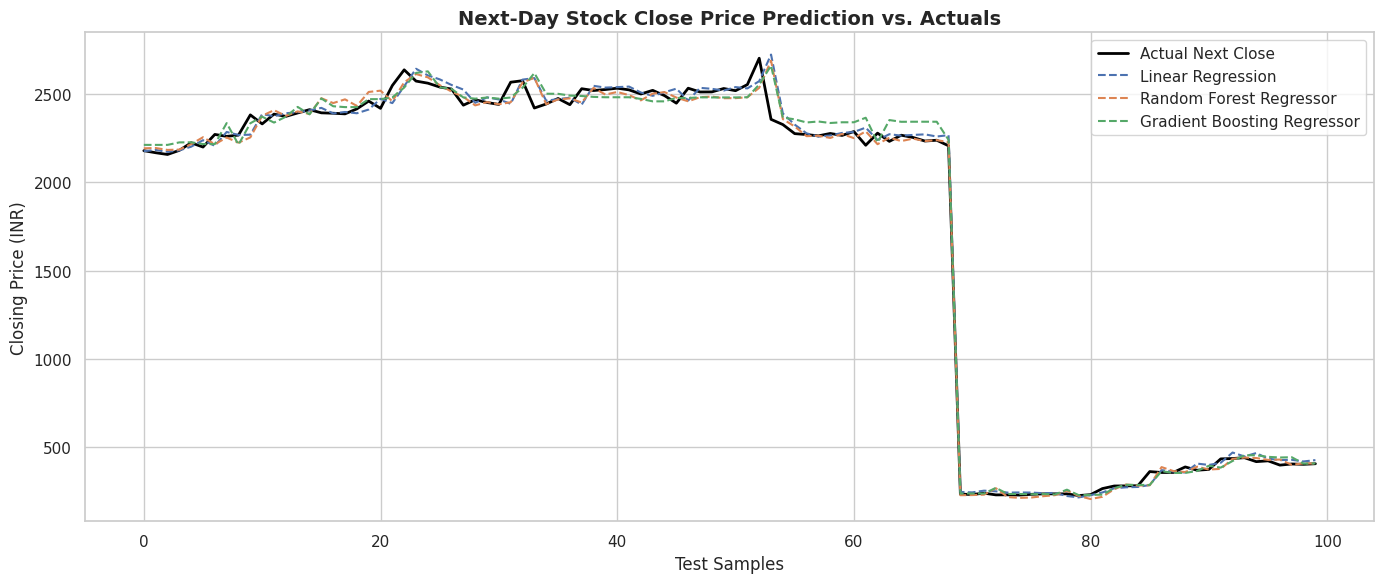

/tmp/ipykernel_1202/928960047.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


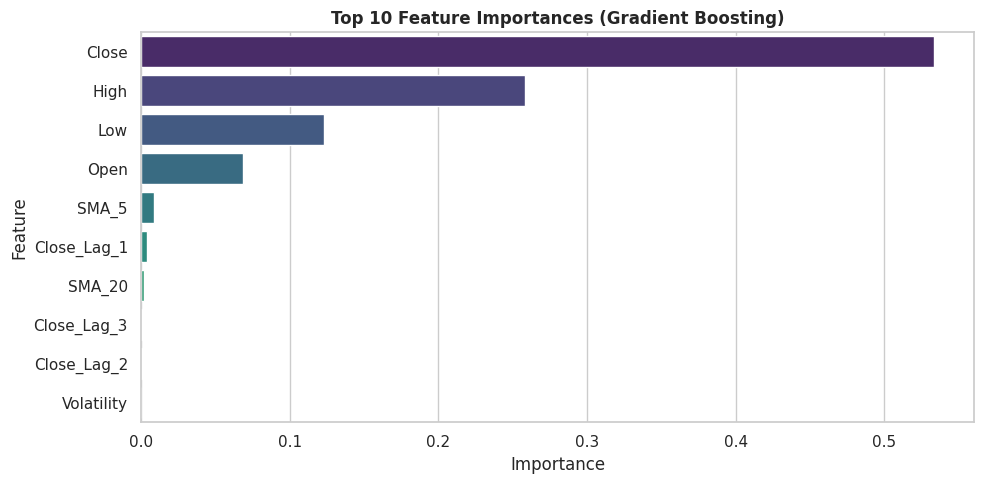

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visual style
sns.set_theme(style="whitegrid")

def train_regression_models(file_path: str):
    # 1. Load Dataset & Sort Chronologically
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    # 2. Feature Engineering & Target Setup
    df['Return_1D'] = df.groupby('Symbol')['Close'].pct_change(1)
    df['Return_3D'] = df.groupby('Symbol')['Close'].pct_change(3)
    df['Return_5D'] = df.groupby('Symbol')['Close'].pct_change(5)
    df['SMA_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5).mean())
    df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
    df['Price_to_SMA20'] = df['Close'] / df['SMA_20']
    df['Volatility_5D'] = df.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(5).std())

    # Lags for prices and news sentiment
    for lag in [1, 2, 3]:
        df[f'Close_Lag_{lag}'] = df.groupby('Symbol')['Close'].shift(lag)
        df[f'Sentiment_Lag_{lag}'] = df.groupby('Symbol')['Sentiment_Score'].shift(lag)

    df['Sentiment_SMA_3D'] = df.groupby('Symbol')['Sentiment_Score'].transform(lambda x: x.rolling(3).mean())

    # Create Target: Next Day's Close Price
    df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)

    # Clean missing values created by lag and rolling calculations
    df_clean = df.dropna().reset_index(drop=True)

    # Predictor variables (X) and Target (y)
    features = [
        'Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility',
        'Return_1D', 'Return_3D', 'Return_5D', 'SMA_5', 'SMA_20', 'Price_to_SMA20',
        'Volatility_5D', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
        'Sentiment_Lag_1', 'Sentiment_Lag_2', 'Sentiment_Lag_3', 'Sentiment_SMA_3D'
    ]

    X = df_clean[features]
    y = df_clean['Next_Close']

    # 3. Time-Series Train-Test Split (80% Train, 20% Test)
    split_idx = int(len(df_clean) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 4. Model Training & Evaluation
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    metrics_list = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        # Calculate evaluation metrics
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        metrics_list.append({
            'Model': name,
            'RMSE (Root Mean Squared Error)': round(rmse, 2),
            'MAE (Mean Absolute Error)': round(mae, 2),
            'R² Score': round(r2, 4)
        })

    # Summary Performance Table
    results_df = pd.DataFrame(metrics_list).set_index('Model')
    print("\n" + "="*60)
    print(" REGRESSION MODEL EVALUATION PERFORMANCE")
    print("="*60)
    print(results_df)

    # 5. Visualizing Actual vs. Predicted Prices
    plt.figure(figsize=(14, 6))
    sample_len = 100  # Visualizing 100 test predictions
    plt.plot(y_test.iloc[:sample_len].values, label='Actual Next Close', color='black', linewidth=2)

    for name, model in models.items():
        preds = model.predict(X_test.iloc[:sample_len])
        plt.plot(preds, label=f'{name}', linestyle='--')

    plt.title('Next-Day Stock Close Price Prediction vs. Actuals', fontsize=14, fontweight='bold')
    plt.xlabel('Test Samples')
    plt.ylabel('Closing Price (INR)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('regression_predictions_comparison.png', dpi=300)
    plt.show()

    # 6. Feature Importance Plot (Gradient Boosting)
    gb_model = models['Gradient Boosting Regressor']
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': gb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Top 10 Feature Importances (Gradient Boosting)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('regression_feature_importance.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    train_regression_models('stock_news_11_columns_6000rows.csv')

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 CLASSIFICATION MODEL EVALUATION PERFORMANCE
                              Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                       
Logistic Regression             0.5332     0.5350  0.9032    0.6720   0.5327
Random Forest Classifier        0.5351     0.5507  0.6613    0.6010   0.5413
Gradient Boosting Classifier    0.5579     0.5594  0.7760    0.6502   0.5765


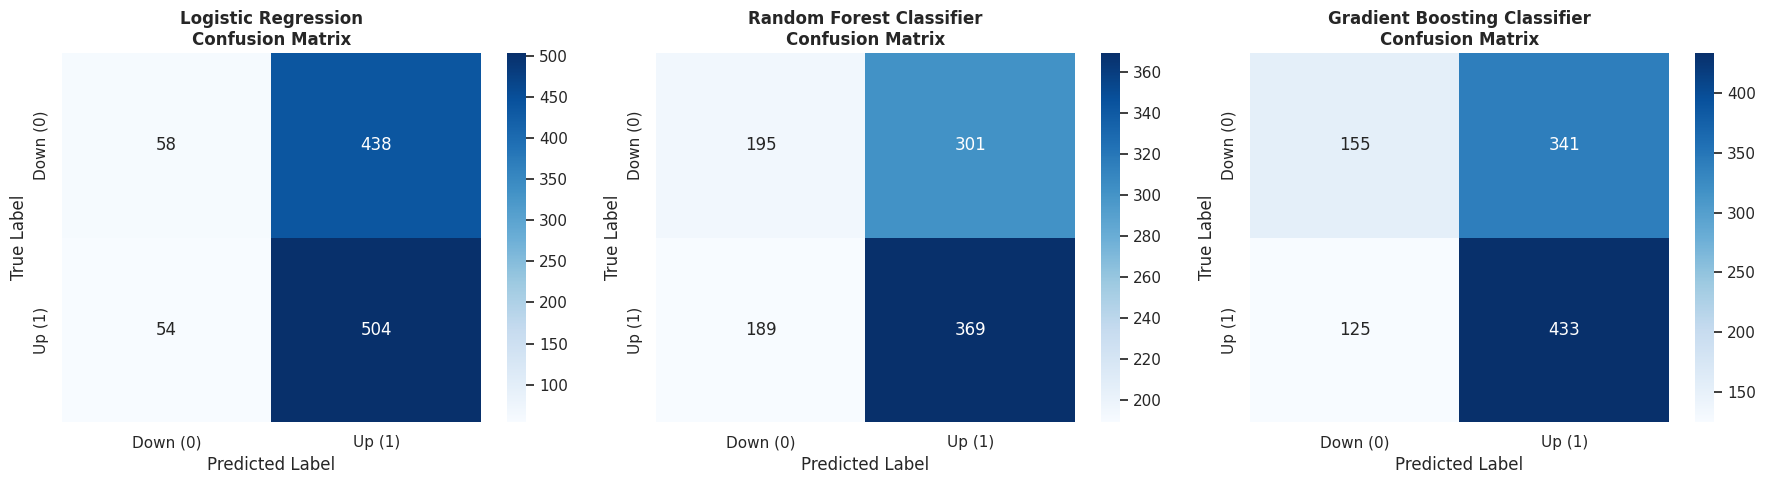

/tmp/ipykernel_1202/3909458103.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


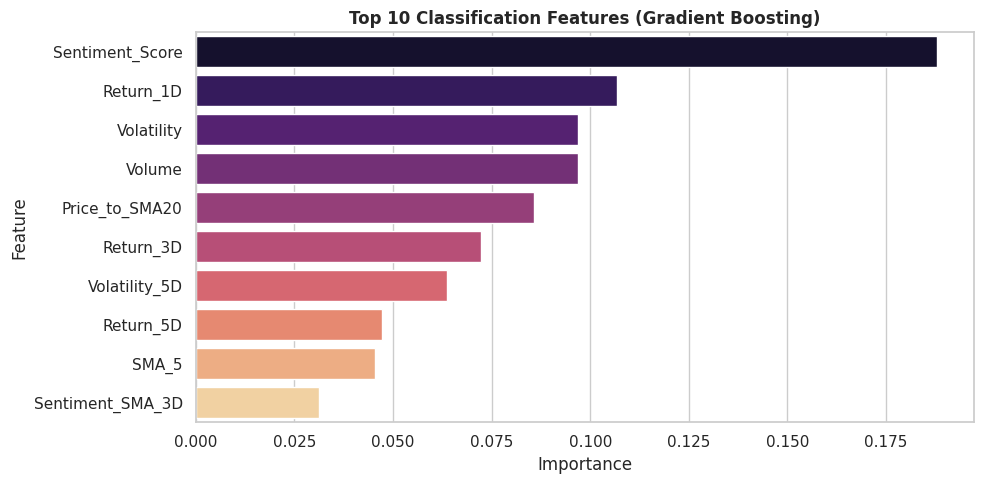

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Set visual style
sns.set_theme(style="whitegrid")

def train_classification_models(file_path: str):
    # 1. Load Dataset & Sort Chronologically
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    # 2. Feature Engineering Pipeline
    df['Return_1D'] = df.groupby('Symbol')['Close'].pct_change(1)
    df['Return_3D'] = df.groupby('Symbol')['Close'].pct_change(3)
    df['Return_5D'] = df.groupby('Symbol')['Close'].pct_change(5)
    df['SMA_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5).mean())
    df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
    df['Price_to_SMA20'] = df['Close'] / df['SMA_20']
    df['Volatility_5D'] = df.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(5).std())

    # Historical Lags for Price & Sentiment
    for lag in [1, 2, 3]:
        df[f'Close_Lag_{lag}'] = df.groupby('Symbol')['Close'].shift(lag)
        df[f'Sentiment_Lag_{lag}'] = df.groupby('Symbol')['Sentiment_Score'].shift(lag)

    df['Sentiment_SMA_3D'] = df.groupby('Symbol')['Sentiment_Score'].transform(lambda x: x.rolling(3).mean())

    # Drop NA rows caused by rolling windows
    df_clean = df.dropna().reset_index(drop=True)

    # Predictor Features & Target Variable (0: Down, 1: Up)
    features = [
        'Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility',
        'Return_1D', 'Return_3D', 'Return_5D', 'SMA_5', 'SMA_20', 'Price_to_SMA20',
        'Volatility_5D', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
        'Sentiment_Lag_1', 'Sentiment_Lag_2', 'Sentiment_Lag_3', 'Sentiment_SMA_3D'
    ]

    X = df_clean[features]
    y = df_clean['Target']

    # 3. Time-Series Train-Test Split (80% Train, 20% Test)
    split_idx = int(len(df_clean) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 4. Initialize Models
    clf_models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

    results = []
    conf_matrices = {}

    # 5. Model Training & Evaluation
    for name, model in clf_models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        roc_auc = roc_auc_score(y_test, probs)

        results.append({
            'Model': name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(roc_auc, 4)
        })

        conf_matrices[name] = confusion_matrix(y_test, preds)

    # Output Performance Table
    results_df = pd.DataFrame(results).set_index('Model')
    print("\n" + "="*70)
    print(" CLASSIFICATION MODEL EVALUATION PERFORMANCE")
    print("="*70)
    print(results_df)

    # 6. Plot Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, (name, cm) in enumerate(conf_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Down (0)', 'Up (1)'], yticklabels=['Down (0)', 'Up (1)'])
        axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')

    plt.tight_layout()
    plt.savefig('classification_confusion_matrices.png', dpi=300)
    plt.show()

    # 7. Plot Feature Importances (Gradient Boosting Classifier)
    gb_clf = clf_models['Gradient Boosting Classifier']
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': gb_clf.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
    plt.title('Top 10 Classification Features (Gradient Boosting)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('classification_feature_importance.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    train_classification_models('stock_news_11_columns_6000rows.csv')

## Hyperparameter Tuning

Now, let's optimize the best-performing regression and classification models, `GradientBoostingRegressor` and `GradientBoostingClassifier`, using `GridSearchCV` to improve prediction performance.

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, roc_auc_score

# Reload and preprocess data for consistency with model training
def get_preprocessed_data(file_path: str):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    df['Return_1D'] = df.groupby('Symbol')['Close'].pct_change(1)
    df['Return_3D'] = df.groupby('Symbol')['Close'].pct_change(3)
    df['Return_5D'] = df.groupby('Symbol')['Close'].pct_change(5)
    df['SMA_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5).mean())
    df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
    df['Price_to_SMA20'] = df['Close'] / df['SMA_20']
    df['Volatility_5D'] = df.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(5).std())

    for lag in [1, 2, 3]:
        df[f'Close_Lag_{lag}'] = df.groupby('Symbol')['Close'].shift(lag)
        df[f'Sentiment_Lag_{lag}'] = df.groupby('Symbol')['Sentiment_Score'].shift(lag)

    df['Sentiment_SMA_3D'] = df.groupby('Symbol')['Sentiment_Score'].transform(lambda x: x.rolling(3).mean())

    # Target for Regression: Next Day's Close Price
    df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)

    # Target for Classification: Existing 'Target' (0 or 1)

    df_clean = df.dropna().reset_index(drop=True)

    features = [
        'Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility',
        'Return_1D', 'Return_3D', 'Return_5D', 'SMA_5', 'SMA_20', 'Price_to_SMA20',
        'Volatility_5D', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
        'Sentiment_Lag_1', 'Sentiment_Lag_2', 'Sentiment_Lag_3', 'Sentiment_SMA_3D'
    ]

    X = df_clean[features]
    y_reg = df_clean['Next_Close']
    y_clf = df_clean['Target']

    split_idx = int(len(df_clean) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]
    y_clf_train, y_clf_test = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]

    return X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test, features

file_path = 'stock_news_11_columns_6000rows.csv'
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test, features = get_preprocessed_data(file_path)

print("Data loaded and preprocessed for hyperparameter tuning.")

Data loaded and preprocessed for hyperparameter tuning.


In [21]:
# 1. Hyperparameter Tuning for GradientBoostingRegressor
print("\n--- Tuning GradientBoostingRegressor ---")

param_grid_gbr = {
    'n_estimators': [50, 100, 200], # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0] # Fraction of samples to be used for fitting the individual base learners
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search_gbr = GridSearchCV(gbr, param_grid_gbr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_gbr.fit(X_train, y_reg_train)

print(f"Best parameters for GBR: {grid_search_gbr.best_params_}")
print(f"Best negative MSE for GBR: {grid_search_gbr.best_score_:.4f}")

best_gbr = grid_search_gbr.best_estimator_
preds_gbr = best_gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_reg_test, preds_gbr))
print(f"RMSE on test set with best GBR: {rmse_gbr:.2f}")

# 2. Hyperparameter Tuning for GradientBoostingClassifier
print("\n--- Tuning GradientBoostingClassifier ---")

param_grid_gbc = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gbc = GradientBoostingClassifier(random_state=42)
grid_search_gbc = GridSearchCV(gbc, param_grid_gbc, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search_gbc.fit(X_train, y_clf_train)

print(f"Best parameters for GBC: {grid_search_gbc.best_params_}")
print(f"Best ROC-AUC for GBC: {grid_search_gbc.best_score_:.4f}")

best_gbc = grid_search_gbc.best_estimator_
probs_gbc = best_gbc.predict_proba(X_test)[:, 1]
roc_auc_gbc = roc_auc_score(y_clf_test, probs_gbc)
print(f"ROC-AUC on test set with best GBC: {roc_auc_gbc:.4f}")


--- Tuning GradientBoostingRegressor ---
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters for GBR: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best negative MSE for GBR: -144458.3613
RMSE on test set with best GBR: 125.10

--- Tuning GradientBoostingClassifier ---
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters for GBC: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best ROC-AUC for GBC: 0.5818
ROC-AUC on test set with best GBC: 0.6017


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# 1. Load data & chronological split (80% train, 20% test)
df = pd.read_csv('stock_news_11_columns_6000rows.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

# Feature Engineering
df['Return_1D'] = df.groupby('Symbol')['Close'].pct_change(1)
df['Return_3D'] = df.groupby('Symbol')['Close'].pct_change(3)
df['Return_5D'] = df.groupby('Symbol')['Close'].pct_change(5)
df['SMA_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5).mean())
df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
df['Price_to_SMA20'] = df['Close'] / df['SMA_20']
df['Volatility_5D'] = df.groupby('Symbol')['Return_1D'].transform(lambda x: x.rolling(5).std())

for lag in [1, 2, 3]:
    df[f'Close_Lag_{lag}'] = df.groupby('Symbol')['Close'].shift(lag)
    df[f'Sentiment_Lag_{lag}'] = df.groupby('Symbol')['Sentiment_Score'].shift(lag)

df['Sentiment_SMA_3D'] = df.groupby('Symbol')['Sentiment_Score'].transform(lambda x: x.rolling(3).mean())

# Create Target: Next Day's Close Price
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)

# Clean missing values created by lag and rolling calculations
df_clean = df.dropna().reset_index(drop=True)

# Predictor variables (X) and Target (y)
features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment_Score', 'Volatility',
    'Return_1D', 'Return_3D', 'Return_5D', 'SMA_5', 'SMA_20', 'Price_to_SMA20',
    'Volatility_5D', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
    'Sentiment_Lag_1', 'Sentiment_Lag_2', 'Sentiment_Lag_3', 'Sentiment_SMA_3D'
]
X = df_clean[features]
y = df_clean['Next_Close']

split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 2. Model evaluation loop
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting (Default)': GradientBoostingRegressor(random_state=42),
    'Gradient Boosting (Tuned)': GradientBoostingRegressor(
        n_estimators=50, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42 # Updated with best params
    )
}

results = []
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'MSE': mean_squared_error(y_test, preds),
        'RMSE': root_mean_squared_error(y_test, preds),
        'R² Score': r2_score(y_test, preds)
    })

eval_df = pd.DataFrame(results)
print(eval_df)

/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.26855e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


                         Model        MAE           MSE        RMSE  R² Score
0            Linear Regression  47.757806  11796.025346  108.609509  0.996863
1             Ridge Regression  47.214730  11735.329390  108.329725  0.996879
2      Random Forest Regressor  60.739401  18975.803809  137.752691  0.994954
3  Gradient Boosting (Default)  59.307050  17656.191202  132.876601  0.995304
4    Gradient Boosting (Tuned)  61.599329  15651.061166  125.104201  0.995838


In [25]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 1. Feature and Target Setup
X = df_clean[features]
y = df_clean['Target']  # Binary target: 1 (Up), 0 (Down)

# Chronological split (80% Train, 20% Test)
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 2. Classifier Definitions
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting (Default)': GradientBoostingClassifier(random_state=42),
    'Gradient Boosting (Tuned)': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.01, max_depth=3, min_samples_split=10, subsample=0.9, random_state=42
    )
}

# 3. Model Evaluation
results = []
for name, model in clf_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

clf_eval_df = pd.DataFrame(results)
print(clf_eval_df)

                         Model  Accuracy  Precision    Recall  F1-Score  \
0          Logistic Regression  0.533461   0.537895  0.912500  0.676821   
1     Random Forest Classifier  0.547801   0.565217  0.673214  0.614507   
2  Gradient Boosting (Default)  0.554493   0.559949  0.783929  0.653274   
3    Gradient Boosting (Tuned)  0.569790   0.562500  0.883929  0.687500   

    ROC-AUC  
0  0.532150  
1  0.557415  
2  0.567027  
3  0.607777  


In [26]:
import pandas as pd
import numpy as np

# 1. Calculate Daily Returns per stock
df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

# 2. Daily Portfolio Returns (Equal-weighted across available stocks)
portfolio_returns = df.groupby('Date')['Daily_Return'].mean().dropna()

# 3. Volatility (Daily & Annualized)
daily_volatility = portfolio_returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

# 4. Cumulative Return & Portfolio Return
cum_returns = (1 + portfolio_returns).cumprod()
total_return = cum_returns.iloc[-1] - 1
annualized_return = (1 + total_return) ** (1 / (len(portfolio_returns) / 252)) - 1

# 5. Sharpe Ratio (Annualized with 5% Risk-Free Rate)
risk_free_rate = 0.05
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

# 6. Value at Risk (Historical VaR at 95% & 99%)
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)

# 7. Maximum Drawdown
running_max = np.maximum.accumulate(cum_returns)
drawdowns = (cum_returns - running_max) / running_max
max_drawdown = drawdowns.min()

print(f"Annualized Return: {annualized_return * 100:.2f}%")
print(f"Annualized Volatility: {annualized_volatility * 100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"95% Historical VaR (1-Day): {var_95 * 100:.2f}%")
print(f"99% Historical VaR (1-Day): {var_99 * 100:.2f}%")
print(f"Maximum Drawdown: {max_drawdown * 100:.2f}%")

Annualized Return: 12277.39%
Annualized Volatility: 643.81%
Sharpe Ratio: 19.06
95% Historical VaR (1-Day): -5.18%
99% Historical VaR (1-Day): -13.02%
Maximum Drawdown: -92.69%


In [27]:
import numpy as np

# Get the last data point from the test set for prediction
# This simulates new data coming in for the 'next day'
latest_data_point = X_test.iloc[[-1]]

# Use the best-performing tuned Gradient Boosting Classifier to predict
# 'best_gbc' was defined in the hyperparameter tuning cell (fc935cba)
next_day_prediction = best_gbc.predict(latest_data_point)
next_day_probability = best_gbc.predict_proba(latest_data_point)[:, 1]

print(f"Predicted Target for the Next Day: {int(next_day_prediction[0])}")
print(f"Probability of 'Up' movement: {next_day_probability[0]:.4f}")

if next_day_prediction[0] == 1:
    print("\nBased on the model's prediction, the signal for the next day is: **BUY (Expect an 'Up' movement)**")
else:
    print("\nBased on the model's prediction, the signal for the next day is: **SELL/HOLD (Expect a 'Down' or 'No Change' movement)**")

print("\nNote: This prediction is based on the last available data point in the test set, not truly new, unseen real-time data.")


Predicted Target for the Next Day: 1
Probability of 'Up' movement: 0.5390

Based on the model's prediction, the signal for the next day is: **BUY (Expect an 'Up' movement)**

Note: This prediction is based on the last available data point in the test set, not truly new, unseen real-time data.


### Identifying 'Best' Stocks for Portfolio Selection

Based on the `portfolio_df` generated, we can identify stocks that meet certain criteria for being 'best' performers. We'll start by looking at the top 10 stocks by average daily return, but you can consider other metrics like `Std_Daily_Return` (risk/volatility), `Avg_Sentiment_Score`, or `Up_Movement_Ratio` (consistency of positive movement) for your selection.

In [31]:
# Display the top 10 stocks by average daily return
print("Top 10 Stocks by Average Daily Return:")
display(portfolio_df.head(10))



Top 10 Stocks by Average Daily Return:


,Symbol,Avg_Daily_Return,Std_Daily_Return,Avg_Close_Price,Avg_Sentiment_Score,Total_Trading_Volume,Count_Trading_Days,Up_Movement_Ratio
29,SBIN,0.052527,0.297739,608.733501,-0.081081,892977643,37,0.540541
33,TECHM,0.044683,0.136479,1507.593346,0.250000,20166314,12,0.500000
11,DRREDDY,0.043932,0.113386,1215.113085,-0.285714,13450557,7,0.571429
14,HCLTECH,0.040298,0.105993,1216.013931,0.047619,125193745,42,0.642857
8,BRITANNIA,0.034908,0.220894,3406.030184,0.022388,63864741,134,0.544776
20,ITC,0.032125,0.175063,337.972451,-0.060000,777260944,50,0.420000
31,TATASTEEL,0.028811,0.211560,55.486454,-0.006897,11623906436,145,0.565517
30,SUNPHARMA,0.026958,0.062836,1417.135678,0.166667,63090145,24,0.625000
16,HINDALCO,0.026812,0.115804,660.201691,-0.133333,126549752,15,0.466667
27,ONGC,0.025530,0.140827,147.085995,0.019231,640440767,52,0.480769
